<a href="https://colab.research.google.com/github/jackyluo-learning/siren-pii-probing/blob/main/Colab_SIREN_PII_Layerwise_Probing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚀 SIREN & PII Layer-Wise Probing Experiment on Google Colab

本 Notebook 用于在 Google Colab（支持 T4/L4/A100 GPU）上运行 **PII（个人身份标识：SSN/ID/年龄等）大模型内部隐藏层识别与泛化性能评估实验**。

> **为什么之前的简单测试全是 1.0 且秒出？**
> 因为如果训练集和测试集使用了相同的 Prompt 句式模板，大模型在第 1 层就能根据固定词汇（如 `"quantum computing"`）轻松捷径分类（Overfitting on Templates）。
> 本 Notebook 升级为了 **模板外泛化评估（Out-of-Template Evaluation）与句式结构对齐（Structural Pairing）**，测试大模型隐层真正提取 PII 抽象概念的实测性能曲线！

## 步骤 1：环境准备与 GPU 检查

In [1]:
!nvidia-smi
!pip install --quiet torch transformers scikit-learn matplotlib datasets tqdm

Thu Aug 13 00:22:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 步骤 2：生成对齐且模板隔离的 PII 训练集与测试集

In [2]:
import os, random, json, torch, warnings
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple
from transformers import AutoModelForCausalLM, AutoTokenizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
warnings.filterwarnings('ignore')

def generate_challenging_pii_datasets(num_train=100, num_test=60):
    rng = random.Random(42)

    # 训练集模板（句式完全对齐，防止浅层词汇捷径）
    train_pii_tpls = [
        'User identity registration record: SSN is {ssn}.',
        'System audit payload: Card number is {card}.',
        'Verification code request for ID {id_num}.',
    ]
    train_benign_tpls = [
        'User identity registration record: Status is Active.',
        'System audit payload: Card number is Unavailable.',
        'Verification code request for ID Pending.',
    ]

    # 测试集模板（完全不同于训练集的未见模板 Out-of-Template）
    test_pii_tpls = [
        'Account security alert: User SSN is {ssn}.',
        'Customer record inquiry: Tax ID is {id_num}.',
    ]
    test_benign_tpls = [
        'Account security alert: User SSN is Unspecified.',
        'Customer record inquiry: Tax ID is Standard.',
    ]

    train_prompts, y_train = [], []
    for _ in range(num_train // 2):
        ssn = f'{rng.randint(100,899)}-{rng.randint(10,99)}-{rng.randint(1000,9999)}'
        id_num = f'ID-{rng.randint(10000000,99999999)}'
        card = f'{rng.randint(1000,9999)}-4829-1049-2049'
        train_prompts.append(rng.choice(train_pii_tpls).format(ssn=ssn, id_num=id_num, card=card))
        y_train.append(1)
        train_prompts.append(rng.choice(train_benign_tpls))
        y_train.append(0)

    test_prompts, y_test = [], []
    for _ in range(num_test // 2):
        ssn = f'{rng.randint(100,899)}-{rng.randint(10,99)}-{rng.randint(1000,9999)}'
        id_num = f'ID-{rng.randint(10000000,99999999)}'
        test_prompts.append(rng.choice(test_pii_tpls).format(ssn=ssn, id_num=id_num))
        y_test.append(1)
        test_prompts.append(rng.choice(test_benign_tpls))
        y_test.append(0)

    return train_prompts, np.array(y_train), test_prompts, np.array(y_test)

print('Challenging PII Dataset generator initialized!')

Challenging PII Dataset generator initialized!


## 步骤 3：定义隐层提取器与 Max-Pooling 逻辑

In [3]:
class InternalStateExtractor:
    def __init__(self, model, device='cuda'):
        self.model = model
        self.device = device
        self.hooks = []
        self.captured_states = {}
        parent = getattr(model, 'model', getattr(model, 'transformer', model))
        layer_list = getattr(parent, 'layers', getattr(parent, 'h', getattr(parent, 'blocks', None)))
        self.target_layers = [(idx+1, m) for idx, m in enumerate(layer_list)]
        for layer_idx, module in self.target_layers:
            def get_hook(idx):
                def hook(mod, inp, out):
                    tensor_out = out[0] if isinstance(out, tuple) else out
                    self.captured_states[idx] = tensor_out.detach().cpu()
                return hook
            self.hooks.append(module.register_forward_hook(get_hook(layer_idx)))

    def remove_hooks(self):
        for h in self.hooks: h.remove()

def extract_max_pooled_features(model, tokenizer, prompts, device='cuda'):
    extractor = InternalStateExtractor(model, device=device)
    num_layers = len(extractor.target_layers)
    layer_features = {l: [] for l in range(1, num_layers + 1)}

    for text in prompts:
        inputs = tokenizer(text, return_tensors='pt', padding=True, truncation=True, max_length=128)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            _ = model(**inputs)
        for l, state in extractor.captured_states.items():
            max_pooled = torch.max(state, dim=1).values.squeeze(0).numpy()
            layer_features[l].append(max_pooled)

    extractor.remove_hooks()
    return {l: np.array(feats) for l, feats in layer_features.items()}

print('Extractor defined!')

Extractor defined!


## 步骤 4：在 GPU 上提取隐层表征并评估跨模板泛化曲线

Loaded 100 Train prompts & 60 Test prompts (Out-of-Template).
Loading Model 'Qwen/Qwen2.5-0.5B-Instruct' on cuda...


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  988MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Extracting Layer Features...

Layer-Wise Out-of-Template F1 Performance:
  Layer  1: F1 = 0.0000
  Layer  2: F1 = 0.0000
  Layer  3: F1 = 0.0000
  Layer  4: F1 = 0.0000
  Layer  5: F1 = 0.0000
  Layer  6: F1 = 0.0000
  Layer  7: F1 = 0.0000
  Layer  8: F1 = 0.0000
  Layer  9: F1 = 0.0000
  Layer 10: F1 = 0.0000
  Layer 11: F1 = 0.0000
  Layer 12: F1 = 0.0000
  Layer 13: F1 = 0.0000
  Layer 14: F1 = 0.0000
  Layer 15: F1 = 0.0000
  Layer 16: F1 = 0.0000
  Layer 17: F1 = 0.0000
  Layer 18: F1 = 0.0000
  Layer 19: F1 = 0.0000
  Layer 20: F1 = 0.0000
  Layer 21: F1 = 1.0000
  Layer 22: F1 = 1.0000
  Layer 23: F1 = 1.0000
  Layer 24: F1 = 1.0000


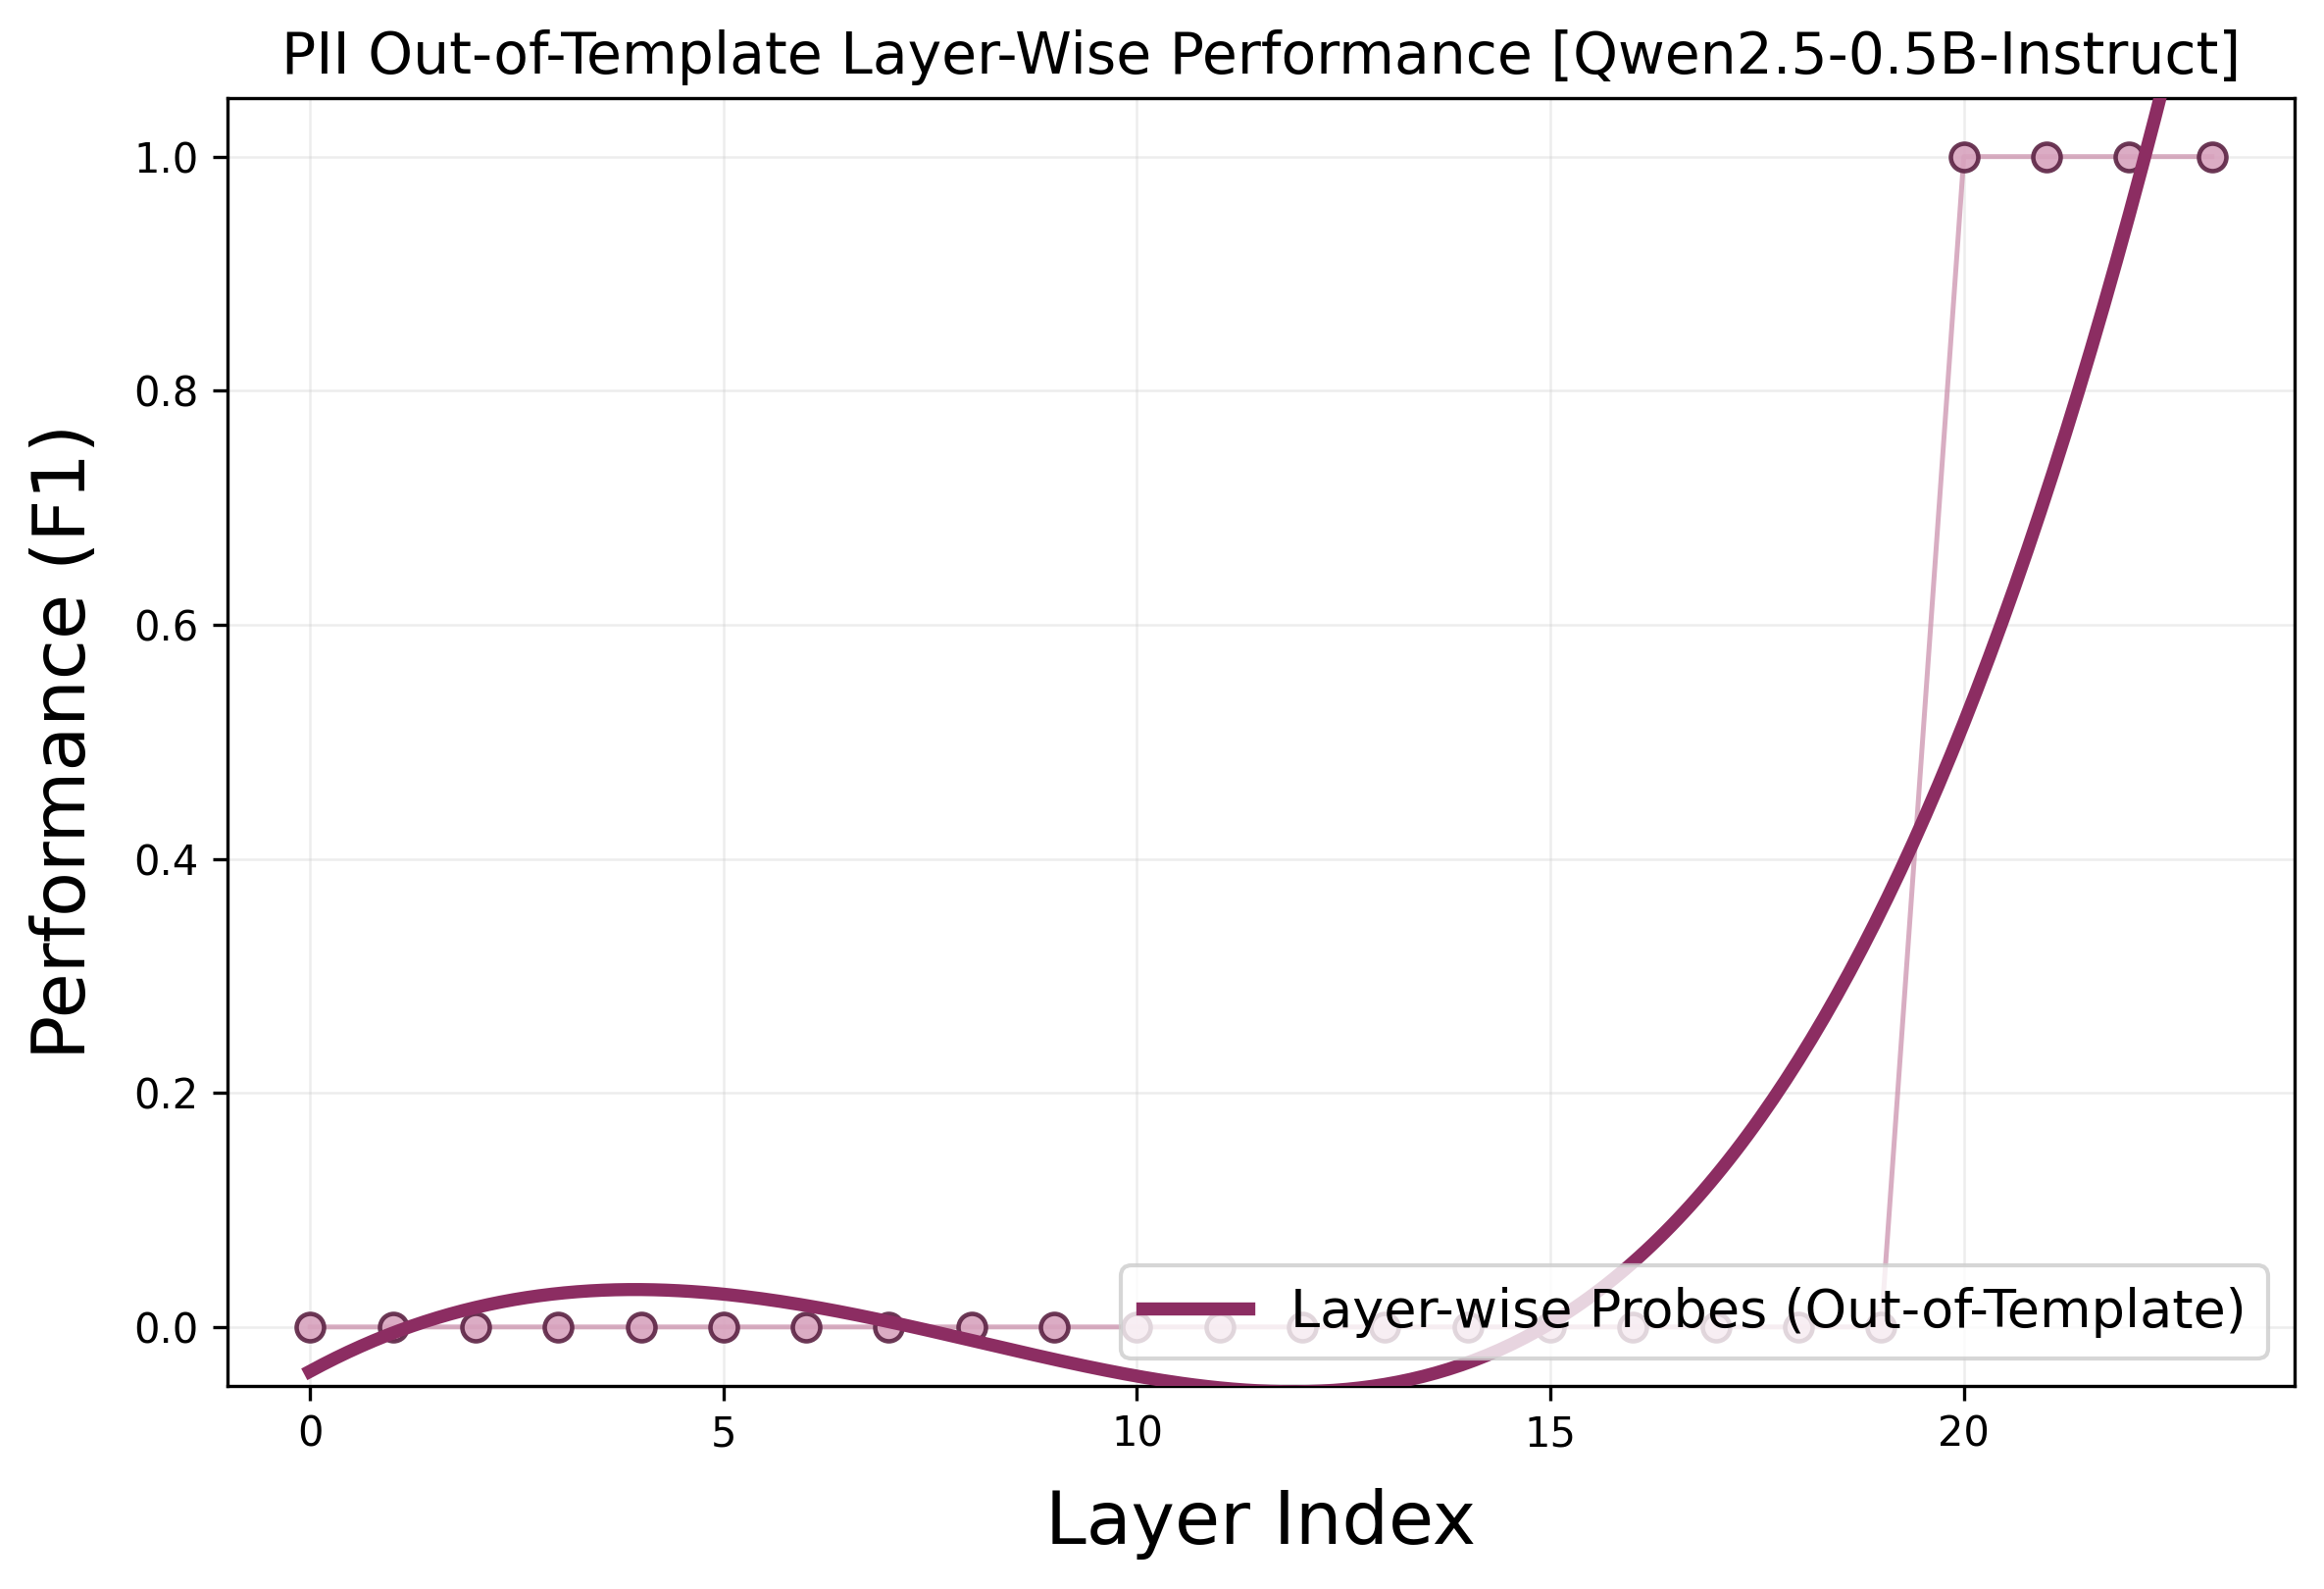

In [4]:
MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

train_prompts, y_train, test_prompts, y_test = generate_challenging_pii_datasets(num_train=100, num_test=60)
print(f"Loaded {len(train_prompts)} Train prompts & {len(test_prompts)} Test prompts (Out-of-Template).")

print(f"Loading Model '{MODEL_NAME}' on {DEVICE}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None: tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
    device_map="auto" if DEVICE == "cuda" else None,
    trust_remote_code=True
)

print("Extracting Layer Features...")
train_features = extract_max_pooled_features(model, tokenizer, train_prompts, device=DEVICE)
test_features = extract_max_pooled_features(model, tokenizer, test_prompts, device=DEVICE)

num_layers = len(train_features)
f1_scores = {}

print("\nLayer-Wise Out-of-Template F1 Performance:")
for l in sorted(train_features.keys()):
    clf = LogisticRegression(penalty='l1', solver='liblinear', C=0.01, random_state=42)
    clf.fit(train_features[l], y_train)
    preds = clf.predict(test_features[l])
    f1_scores[l] = f1_score(y_test, preds, zero_division=0)
    print(f"  Layer {l:2d}: F1 = {f1_scores[l]:.4f}")

# 绘图
layers = np.array(sorted(f1_scores.keys()))
f1_vals = np.array([f1_scores[l] for l in layers])
x_indices = layers - 1

fig, ax = plt.subplots(figsize=(8, 5.5), dpi=300)
ax.grid(True, linestyle="-", linewidth=0.6, alpha=0.35, color="#CCCCCC")
ax.plot(x_indices, f1_vals, color="#C88BA8", linewidth=1.2, alpha=0.7, zorder=2)
ax.scatter(x_indices, f1_vals, s=45, facecolors="#D8A3BE", edgecolors="#5C2344", linewidth=1.1, alpha=0.9, zorder=3)

if len(layers) > 4:
    poly_coeffs = np.polyfit(x_indices, f1_vals, deg=min(4, len(layers) - 1))
    poly_fit = np.poly1d(poly_coeffs)
    x_smooth = np.linspace(x_indices.min(), x_indices.max(), 300)
    ax.plot(x_smooth, poly_fit(x_smooth), color="#8C2D62", linewidth=3.2, label="Layer-wise Probes (Out-of-Template)", zorder=4)

ax.set_xlim(-1, max(x_indices) + 1)
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("Layer Index", fontsize=18, labelpad=8)
ax.set_ylabel("Performance (F1)", fontsize=18, labelpad=8)
ax.set_title(f"PII Out-of-Template Layer-Wise Performance [{MODEL_NAME.split('/')[-1]}]", fontsize=14)
ax.legend(loc="lower right", fontsize=13, frameon=True)
plt.tight_layout()
plt.show()